<a href="https://colab.research.google.com/github/jessguerzoni/C111/blob/main/Cap6_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:

iris = sns.load_dataset("iris")
setosa = iris[iris["species"] == "setosa"]

# 2. Selecionar apenas as variáveis numéricas
numericas = setosa.drop(columns="species")

# 3. Matriz de correlação (Pearson)
corr = numericas.corr()
print("Matriz de correlação (setosa):\n")
print(corr.round(3))

# 4. Heatmap com os valores anotados
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlação entre variáveis - Iris setosa")
plt.tight_layout()
plt.show()

# 5. Ranking dos pares de variáveis (sem repetições e sem a diagonal)
mascara = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pares = (corr.where(mascara)
             .stack()
             .sort_values(ascending=False))
pares.index.names = ["variável 1", "variável 2"]
print("\nPares ordenados por correlação:\n")
print(pares.round(3))

# 6. Par mais correlacionado
(v1, v2), valor = pares.index[0], pares.iloc[0]
print(f"\nMais correlacionadas: {v1} x {v2} (r = {valor:.3f})")

In [ ]:

titanic = sns.load_dataset("titanic")

dados = titanic.dropna(subset=["age"])


plt.figure(figsize=(9, 5))
sns.histplot(
    data=dados,
    x="age",
    hue="sex",
    kde=True,
    bins=30,
    stat="density",
    common_norm=False,
    palette={"male": "tab:pink", "female": "tab:green"},
    alpha=0.4,
)

plt.title("Distribuição das idades dos passageiros do Titanic por sexo")
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.tight_layout()
plt.show()

In [ ]:

titanic = sns.load_dataset("titanic")
dados = titanic.dropna(subset=["age"])

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=dados,
    x="class",
    y="age",
    hue="sex",
    order=["First", "Second", "Third"],
    palette={"male": "tab:blue", "female": "tab:red"},
    showmeans=True,   # marca a média (triângulo) além da mediana (linha)
    meanprops={"marker": "^", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 7},
)

plt.title("Distribuição das idades por classe e sexo - Titanic")
plt.xlabel("Classe")
plt.ylabel("Idade (anos)")
plt.legend(title="Sexo")
plt.tight_layout()
plt.show()

resumo = (dados.groupby(["class", "sex"], observed=True)["age"]
               .describe()[["count", "mean", "50%", "std", "min", "max"]]
               .round(1))
print(resumo)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar o dataset e remover valores ausentes (horsepower tem NaN)
mpg = sns.load_dataset("mpg")
dados = mpg.dropna(subset=["horsepower", "mpg"])

# 2. Correlação entre as variáveis
r = dados["horsepower"].corr(dados["mpg"])
print(f"Correlação de Pearson (horsepower x mpg): {r:.3f}")

# 3. Dispersão com duas linhas de tendência
plt.figure(figsize=(9, 6))
sns.scatterplot(data=dados, x="horsepower", y="mpg", alpha=0.6,
                color="tab:blue", label="Veículos")

# Ajuste linear
sns.regplot(data=dados, x="horsepower", y="mpg", scatter=False,
            order=1, color="tab:red", label="Tendência linear")

# Ajuste polinomial (grau 2)
sns.regplot(data=dados, x="horsepower", y="mpg", scatter=False,
            order=2, color="tab:green", label="Tendência quadrática")

plt.title("Relação entre potência e consumo de combustível")
plt.xlabel("Potência (horsepower)")
plt.ylabel("Consumo (mpg - milhas por galão)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv("paises.csv", sep=";", decimal=",")

colunas = [
    "GDP ($ per capita)",
    "Literacy (%)",
    "Infant mortality (per 1000 births)",
    "Phones (per 1000)",
]
dados = df[colunas]

corr = dados.corr()
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Correlação entre indicadores socioeconômicos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_677/152781409.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


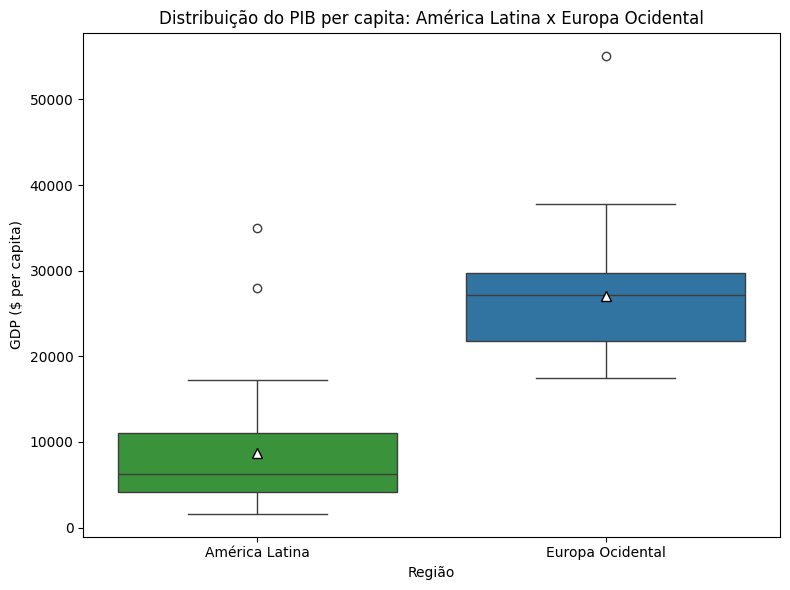

                  count     mean      50%     std      min      max
Grupo                                                              
América Latina     45.0   8682.0   6300.0  6658.0   1600.0  35000.0
Europa Ocidental   28.0  27046.0  27200.0  7619.0  17500.0  55100.0


In [12]:
df = pd.read_csv("paises.csv", sep=";", decimal=",")
df.columns = df.columns.str.strip()
df["Region"] = df["Region"].str.strip()

# 2. Filtrar as duas regiões e mapear nomes mais legíveis
regioes = {
    "LATIN AMER. & CARIB": "América Latina",
    "WESTERN EUROPE": "Europa Ocidental",
}
dados = df[df["Region"].isin(regioes)].copy()
dados["Grupo"] = dados["Region"].map(regioes)
dados = dados.dropna(subset=["GDP ($ per capita)"])

# 3. Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=dados,
    x="Grupo",
    y="GDP ($ per capita)",
    order=["América Latina", "Europa Ocidental"],
    palette=["tab:green", "tab:blue"],
    showmeans=True,
    meanprops={"marker": "^", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 7},
)

plt.title("Distribuição do PIB per capita: América Latina x Europa Ocidental")
plt.xlabel("Região")
plt.ylabel("GDP ($ per capita)")
plt.tight_layout()
plt.show()

# 4. Resumo numérico de apoio
print(dados.groupby("Grupo")["GDP ($ per capita)"]
           .describe()[["count", "mean", "50%", "std", "min", "max"]]
           .round(0))

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ler o arquivo e limpar nomes de colunas
df = pd.read_csv("paises.csv", sep=";", decimal=",")
df.columns = df.columns.str.strip()

# Converter explicitamente as colunas necessárias para numérico
df["Literacy (%)"] = pd.to_numeric(df["Literacy (%)"], errors="coerce")
df["Infant mortality (per 1000 births)"] = pd.to_numeric(df["Infant mortality (per 1000 births)"], errors="coerce")

# 2. Remover valores ausentes nas duas variáveis
dados = df.dropna(subset=["Literacy (%)", "Infant mortality (per 1000 births)"])

# 3. Correlação para apoiar a interpretação
r = dados["Literacy (%)"].corr(dados["Infant mortality (per 1000 births)"])
print(f"Correlação de Pearson: {r:.3f}")

# 4. Regplot com linha de regressão customizada
plt.figure(figsize=(9, 6))
sns.regplot(
    data=dados,
    x="Literacy (%)",
    y="Infant mortality (per 1000 births)",
    scatter_kws={"alpha": 0.6, "color": "tab:blue"},   # pontos
    line_kws={"color": "red", "linewidth": 2},         # linha de regressão
)

plt.title("Alfabetização x Mortalidade infantil")
plt.xlabel("Taxa de alfabetização (%)")
plt.ylabel("Mortalidade infantil (por 1000 nascimentos)")
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv("space.csv", sep=";", thousands=",")
df.columns = df.columns.str.strip()

COL_CUSTO = "Cost"
COL_STATUS = "Status Rocket"

df[COL_CUSTO] = pd.to_numeric(df[COL_CUSTO], errors="coerce")
dados = df[df[COL_CUSTO] > 0]

dados = dados[dados[COL_STATUS].isin(["StatusActive", "StatusRetired"])]

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=dados,
    x=COL_STATUS,
    y=COL_CUSTO,
    hue=COL_STATUS,
    legend=False,
    order=["StatusActive", "StatusRetired"],
    palette={"StatusActive": "tab:green", "StatusRetired": "tab:orange"},
    showmeans=True,
    meanprops={"marker": "^", "markerfacecolor": "green",
               "markeredgecolor": "pink", "markersize": 7},
)
plt.yscale("log")
plt.title("Custo das missões por status do foguete")
plt.xlabel("Status do foguete")
plt.ylabel("Custo (milhões de US$, escala log)")
plt.tight_layout()
plt.show()

# 5. Resumo numérico de apoio
print(dados.groupby(COL_STATUS)[COL_CUSTO]
           .describe()[["count", "mean", "50%", "std", "min", "max"]]
           .round(1))